# Programa de Capacitação de Processamento Digital de Sinais


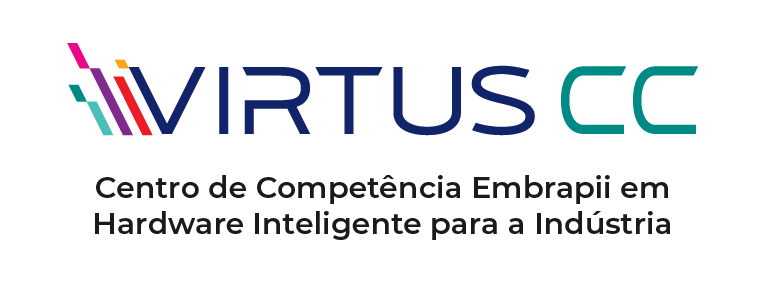


### Desenvolvido por:
-   Elmer Pimentel Farias


## Exercícios do Capítulo 3 — Processamento Digital de Sinais

Capítulo 3 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 3

**O Capítulo 3 apresenta os conceitos de DFT e implementações de FFT:**

- Análise de Frequência de Sinais Discretos: Por que representar sinais no domínio da frequência.

- A Transformada de Fourier Discreta (DFT): A versão computacional da análise de Fourier.

- Definição e Propriedades Principais.

A **Transformada Rápida de Fourier (FFT)** não é uma nova transformada, mas sim uma família de algoritmos extremamente eficientes para calcular a DFT.

- A ineficiência do cálculo direto da DFT: O cálculo da DFT diretamente por sua definição exige um número de operações na ordem de **$O(N^2)$**, onde $N$ é o número de amostras. Isso torna o processo inviável para sequências longas.

- O princípio da "divisão e conquista": A base dos algoritmos FFT é quebrar uma DFT de $N$ pontos em DFTs menores, de forma recursiva. Os resultados dessas DFTs menores são então combinados para produzir o resultado final.


- Algoritmos Clássicos: Os algoritmos mais comuns que implementam essa estratégia são:
    - Decimação no Tempo (DIT - *Decimation-In-Time*)
    - Decimação na Frequência (DIF - *Decimation-In-Frequency*)


- O ganho de performance: Ao utilizar a estratégia de "divisão e conquista", os algoritmos FFT reduzem drasticamente a complexidade computacional para a ordem de **$O(N \log N)$**, representando um ganho de performance massivo e tornando a análise de frequência uma ferramenta prática na computação moderna.

- Métodos Overlap-Add e Overlap-Save 

- Convolução Circular vs. Linear: Como a DFT modifica a operação de convolução e como usar isso a nosso favor.

## Objetivos Principais:
-  Implementar DFT manualmente e verificar propriedades como simetria e periodicidade.
-   Implementar o algoritmo da FFT e comparar tempo de execução e resultado com a DFT
-  Simular convolução circular via DFT e comparar com convolução linear.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

# Importando as Bibliotecas


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  
from numba import njit, jit , vectorize , prange

#  Transformada Discreta de Fourier (DFT) e Análise do Código

## 1. Introdução à DFT

A **Transformada Discreta de Fourier (DFT)** permite transformar um sinal do **domínio do tempo** para o **domínio da frequência**.


Para um sinal discreto \(x[n]\) de comprimento \(N\), a DFT é:

$$
X[k] \;=\; \sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi k n}{N}}, \qquad k = 0,1,\dots,N-1.
$$

Para normalização (preservar energia), usa-se:

$$
X_{\mathrm{norm}}[k] \;=\; \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi k n}{N}}.
$$


## 2. Zero Padding e Truncamento

Quando o tamanho do sinal \( L \) **não coincide** com o tamanho escolhido para a DFT \( N \), duas situações podem ocorrer:

### 2.1 Zero Padding (\( L < N \))
Adiciona zeros ao final do sinal para que ele tenha comprimento \( N \).  
Essa técnica **não altera o conteúdo do sinal**, mas aumenta a **resolução na frequência**.

$$
x_{zp}[n] =
\begin{cases}
x[n], & 0 \le n < L,\\[4pt]
0, & L \le n < N.
\end{cases}
$$

### 2.2 Truncamento (\( L > N \))
Corta as amostras excedentes do sinal para que ele caiba em \( N \).  
Essa técnica **modifica o sinal original**, podendo introduzir distorções no espectro.

$$
x_{\text{tr}}[n] = x[n], \qquad 0 \le n < N.
$$

Sinal x1[n]: 50 amostras
Sinal x2[n]: 100 amostras


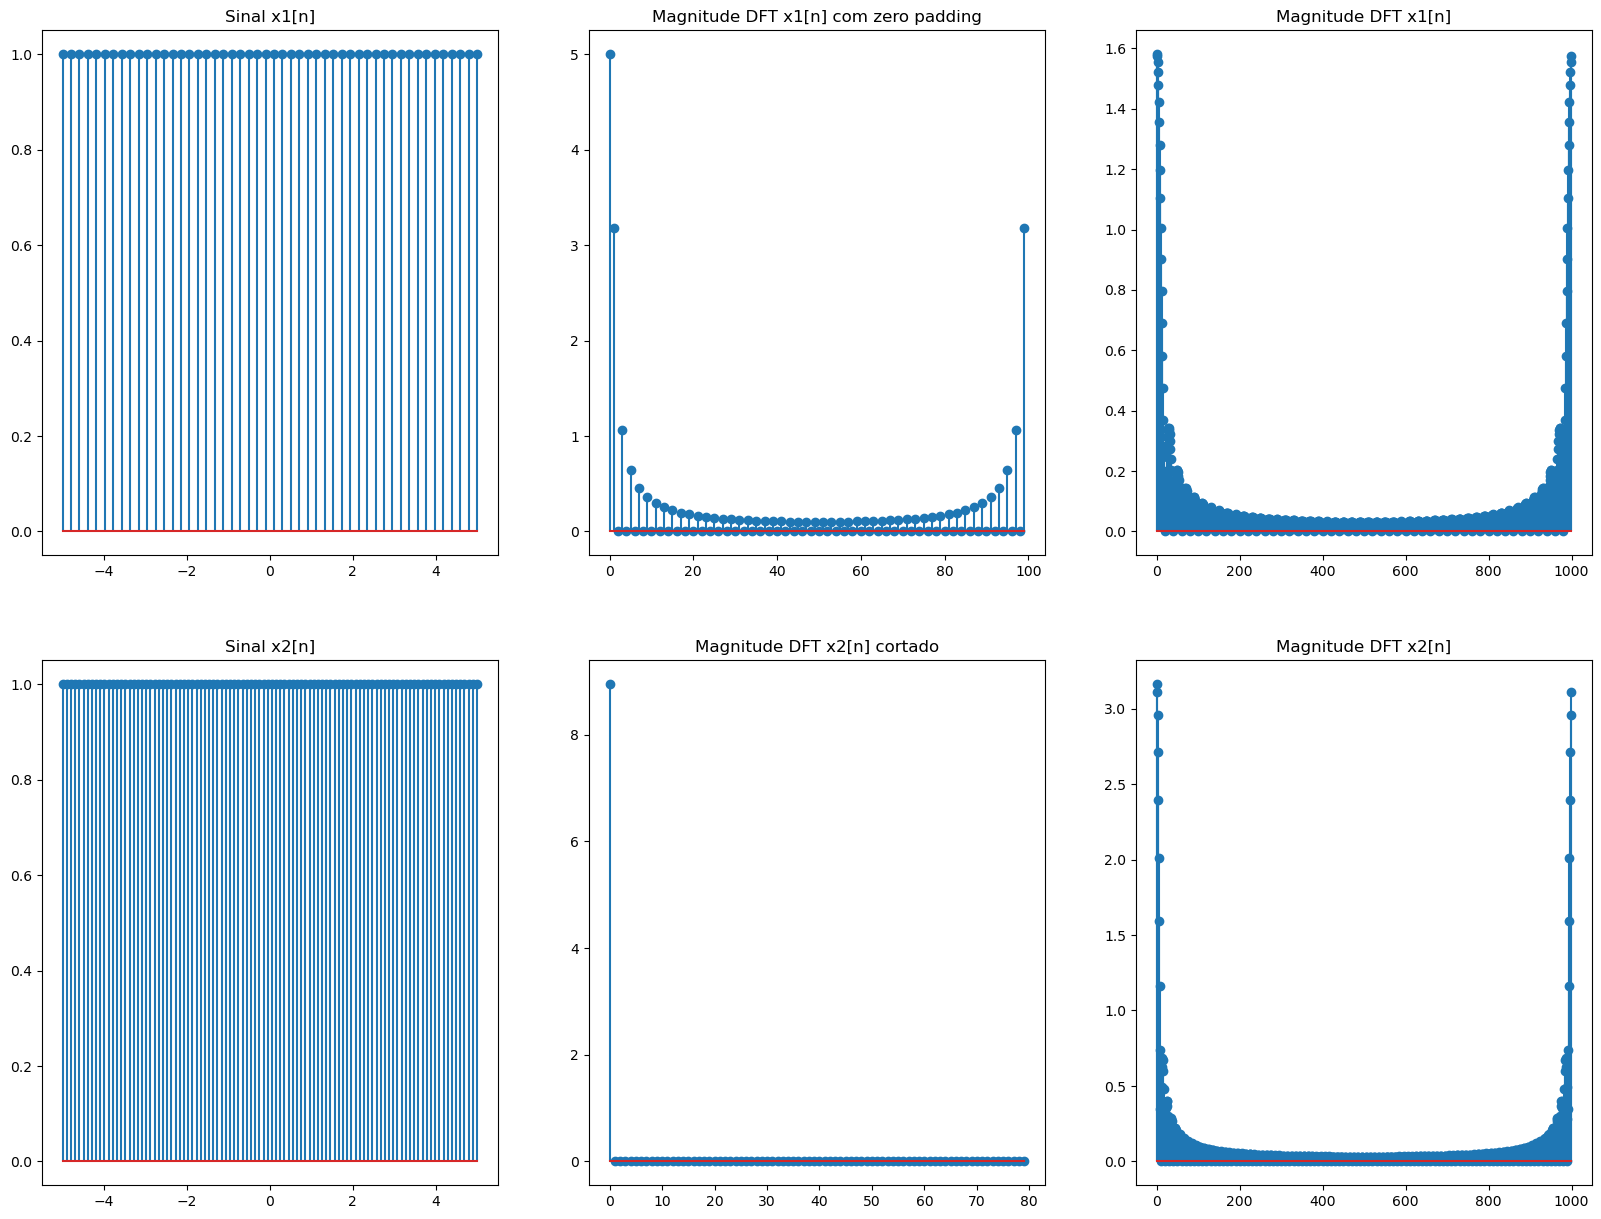

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT

L1= 50
N1= 100

L2=100
N2=80 

n1= np.linspace(-5,5,L1)
n2= np.linspace(-5,5,L2)

x1= np.where(np.abs(n1)<10,1,0) #sinal retangular
x2= np.where(np.abs(n2)<10,1,0) #sinal retangular



X1_DFT= DFT_func(x1,N=N1) #DFT do sinal x1, L1=50 < N1=100, com zero padding

X2_DFT= DFT_func(x2,N=N2) #DFT do sinal x2, L2=100 > N2=80, truncado

X3_DFT= DFT_func(x1,N=1000) #DFT do sinal x2, L2=100 < N=1000

X4_DFT= DFT_func(x2,N=1000) #DFT do sinal x2, L2=100 > N=1000

fig , axs= plt.subplots(2,3, figsize=(20,15))

axs[0,0].stem(n1,x1)
axs[0,0].set_title('Sinal x1[n]')
axs[1,0].stem(n2,x2)
axs[1,0].set_title('Sinal x2[n]')
axs[0,1].stem(np.abs(X1_DFT))
axs[0,1].set_title('Magnitude DFT x1[n] com zero padding')
axs[1,1].stem(np.abs(X2_DFT))
axs[1,1].set_title('Magnitude DFT x2[n] cortado')
axs[0,2].stem(np.abs(X3_DFT))
axs[0,2].set_title('Magnitude DFT x1[n]')
axs[1,2].stem(np.abs(X4_DFT))
axs[1,2].set_title('Magnitude DFT x2[n]')

print('Sinal x1[n]:', len(x1), 'amostras')
print('Sinal x2[n]:', len(x2), 'amostras')

## Otimização de Código

Primeira Compilação com Numba (pode demorar um pouco)...
Compilação concluída. Iniciando os testes de tempo...
Para N= 64...
Tempo DFT com python puro: 0.0035826999956043437 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0007751999946776778 segundos
Para N= 128...
Tempo DFT com python puro: 0.013811999997415114 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0002666999935172498 segundos
Para N= 256...
Tempo DFT com python puro: 0.05473070000152802 segundos
Tempo DFT tempo com python com njit paralelizado: 0.00036920000275131315 segundos
Para N= 512...
Tempo DFT com python puro: 0.22018969999771798 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0007878000033088028 segundos
Para N= 1024...
Tempo DFT com python puro: 0.8845157000032486 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0021876000027987175 segundos
Para N= 2048...
Tempo DFT com python puro: 3.551807899995765 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0048

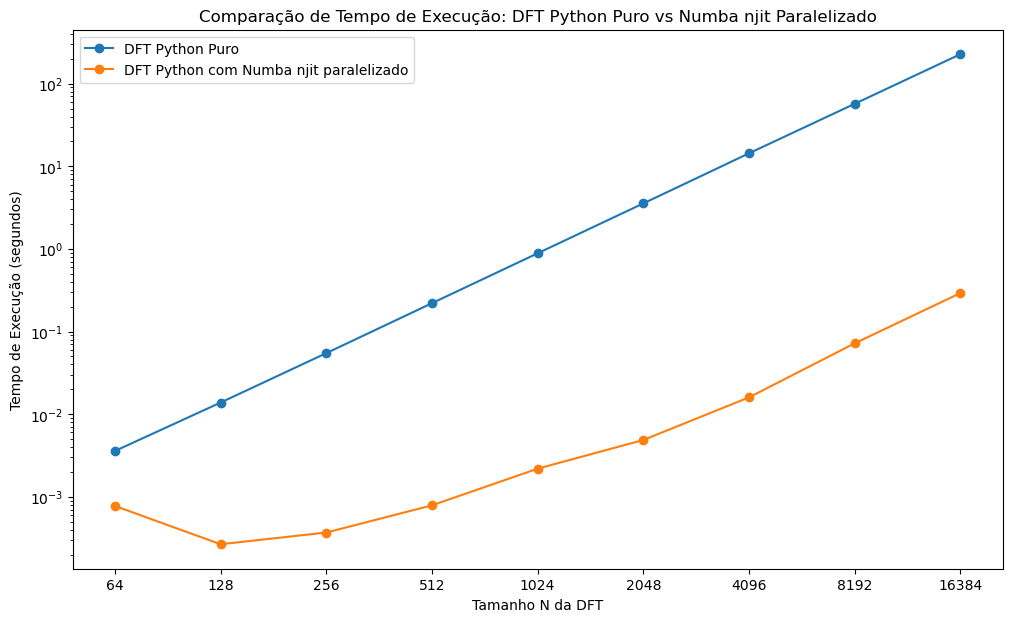

In [73]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func_Numba(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


dft_tamanhos= [64,128,256,512,1024,2048,4096,8192,16384]        
tempo_DFT= []
tempo_DFT_Numba= []

fs= 1000 # frequência de amostragem
f= 50 # frequência do sinal
A= 1 # amplitude do sinal
t= np.arange(-1,1,1/fs) # vetor tempo
x= A * np.sin(2 * np.pi * f * t) # sinal senoidal
x_noise= x + 0.5 * np.random.randn(len(t)) # sinal com ruído

print("Primeira Compilação com Numba (pode demorar um pouco)...")
DFT_func_Numba(x_noise, 100) # Compilação inicial com Numba
print("Compilação concluída. Iniciando os testes de tempo...")

for N in dft_tamanhos:
    print(f'Para N= {N}...')
    
    start_time= time.perf_counter()
    X_DFT= DFT_func(x_noise,N)
    end_time= time.perf_counter()
    time_spent= end_time - start_time
    tempo_DFT.append(time_spent)
    print(f'Tempo DFT com python puro: {time_spent} segundos')

    start_time_n= time.perf_counter()
    X_DFT= DFT_func_Numba(x_noise,N)
    end_time_n= time.perf_counter()
    time_spent_n= end_time_n - start_time_n
    tempo_DFT_Numba.append(time_spent_n)
    print(f'Tempo DFT tempo com python com njit paralelizado: {time_spent_n} segundos')

plt.figure(figsize=(12,7))
plt.plot(dft_tamanhos, tempo_DFT, marker='o', label='DFT Python Puro')
plt.plot(dft_tamanhos, tempo_DFT_Numba, marker='o', label='DFT Python com Numba njit paralelizado')
plt.yscale('log')
plt.xscale('log', base=2)
plt.xlabel('Tamanho N da DFT')
plt.ylabel('Tempo de Execução (segundos)')
plt.title('Comparação de Tempo de Execução: DFT Python Puro vs Numba njit Paralelizado')
plt.xticks (dft_tamanhos, labels=dft_tamanhos)
plt.legend()
plt.show()


    

A periodicidade da DFT, $X[k] = X[k+N]$, existe porque a base da transformada, os exponenciais complexos $W_N = e^{-j\frac{2\pi}{N}}$, são eles próprios periódicos. Vamos provar e visualizar isso.

A ideia é mostrar que os "vetores de base" (os exponenciais complexos) usados para calcular $X[k]$ são os mesmos usados para calcular $X[k+N]$.

O termo exponencial na DFT é $W_N^{kn} = e^{-j\frac{2\pi kn}{N}}$. Vamos ver o que acontece quando usamos $k' = k+N$:

$$
\begin{align*}
W_N^{(k+N)n} &= e^{-j\frac{2\pi(k+N)n}{N}} \\
             &= e^{-j\left(\frac{2\pi kn}{N} + \frac{2\pi Nn}{N}\right)} \\
             &= e^{-j\frac{2\pi kn}{N}} \cdot e^{-j2\pi n}
\end{align*}
$$

Pela Relação de Euler, sabemos que $e^{-j2\pi n} = \cos(2\pi n) - j\sin(2\pi n)$. Como $n$ é sempre um inteiro, $\cos(2\pi n) = 1$ e $\sin(2\pi n) = 0$. Portanto, $e^{-j2\pi n} = 1$.

Isso nos prova que:

$$
W_N^{(k+N)n} = W_N^{kn} \cdot 1 = W_N^{kn}
$$

Os termos exponenciais para o índice $k$ são idênticos aos termos para o índice $k+N$. Consequentemente, o somatório da DFT para $X[k]$ e $X[k+N]$ será o mesmo.

>>> Testando com uma chamada válida (k=3, N=10)...
Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N =10
Vamos provar que os termos para k=3 e (k + N)=13 são idênticos.
Verificação numérica: Os 10 termos são iguais? Sim.


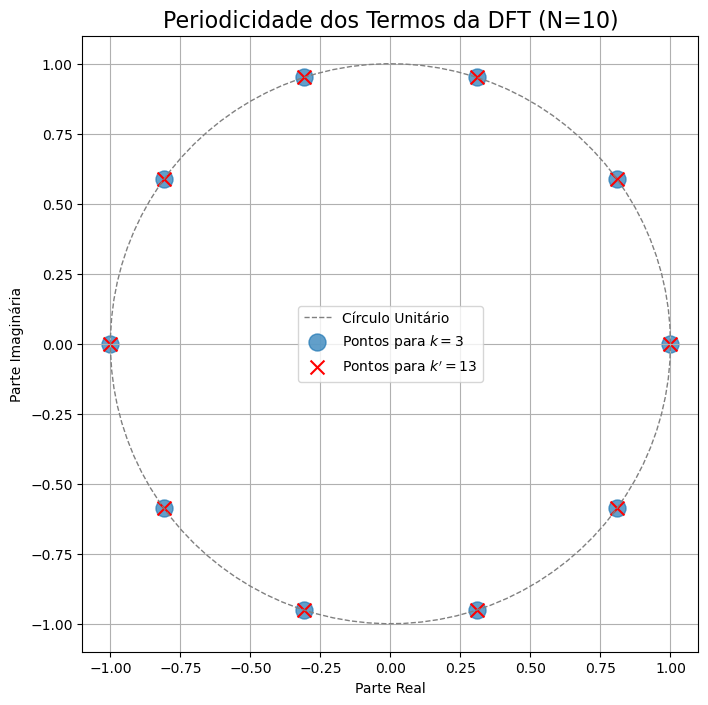

>>> Testando com uma chamada inválida (k=12, N=10)...
Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N =20
Vamos provar que os termos para k=12 e (k + N)=32 são idênticos.
Verificação numérica: Os 20 termos são iguais? Sim.


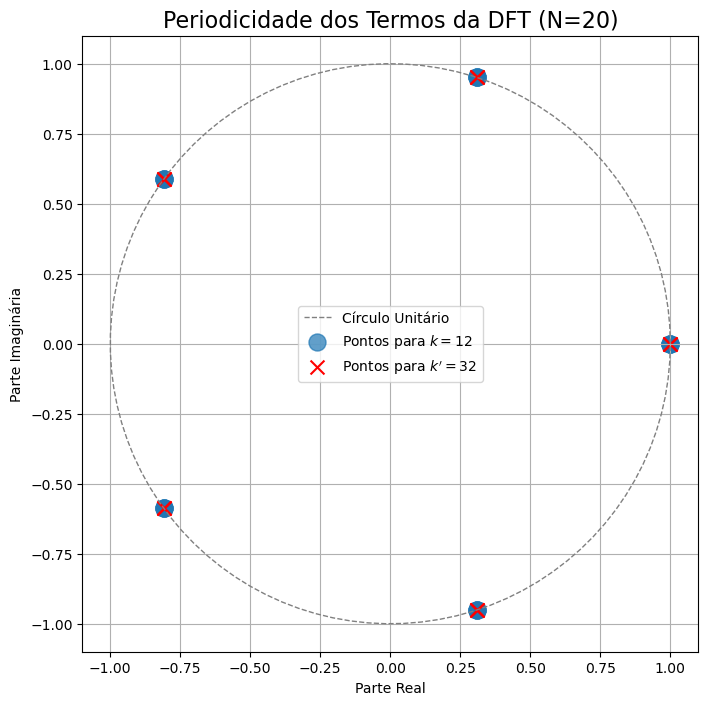

>>> Testando com uma chamada inválida no limite (k=10, N=10)...
Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N =10
ERRO: 'k_test' (10) deve ser menor que N (10).
A função será encerrada.


In [2]:
def DFT_periodic(N,k_test=2 ):
    print(f"Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N ={N}")

    if k_test >= N:
        print(f"ERRO: 'k_test' ({k_test}) deve ser menor que N ({N}).")
        print("A função será encerrada.")
        return # Encerra a função aqui.


    print(f"Vamos provar que os termos para k={k_test} e (k + N)={k_test+N} são idênticos.")
    n= np.arange(N)
    k= np.exp(-1j * 2 * np.pi * k_test * n / N)
    k_plus_N= np.exp(-1j * 2 * np.pi * (k_test + N) * n / N)

    print(f"Verificação numérica: Os {N} termos são iguais? {'Sim.' if np.allclose(k, k_plus_N) else 'Não.'}")

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'aspect': 'equal'})
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', linewidth=1, label='Círculo Unitário')
    ax.scatter(k.real, k.imag, marker='o', s=150, alpha=0.7, label=f'Pontos para $k={k_test}$')
    ax.scatter(k_plus_N.real, k_plus_N.imag, marker='x', s=100, color='red', label=f'Pontos para $k\'={k_test+N}$')
    ax.set_title(f'Periodicidade dos Termos da DFT (N={N})', fontsize=16)
    ax.set_xlabel('Parte Real')
    ax.set_ylabel('Parte Imaginária')
    ax.grid(True)
    ax.legend()
    plt.show()

print(">>> Testando com uma chamada válida (k=3, N=10)...")
DFT_periodic(N=10, k_test=3)


print(">>> Testando com uma chamada inválida (k=12, N=10)...")
DFT_periodic(N=20, k_test=12)


print(">>> Testando com uma chamada inválida no limite (k=10, N=10)...")
DFT_periodic(N=10, k_test=10)

# Propriedades de Simetria Conjugada da DFT

A **Transformada Discreta de Fourier (DFT)** é uma ferramenta fundamental na Análise de Sinais e Processamento Digital de Sinais (DSP).
Para um sinal discreto no tempo $x[n]$ de comprimento $N$, a DFT é definida por:

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}, \quad k = 0, 1, 2, \dots, N-1
$$

onde $X[k]$ são os coeficientes no **domínio da frequência**.

## Simetria Conjugada da DFT

Se a sequência $x[n]$ é **real**, os coeficientes da DFT satisfazem a importante propriedade de **simetria conjugada**:

$$
X^{*}[k] = X[N-k]
$$

Essa relação mostra que a DFT de sinais reais não é independente em todos os $N$ pontos de frequência:
os valores nos índices positivos e negativos (em sentido circular) estão relacionados pelo conjugado.

## Implicações da Simetria Conjugada

A partir da relação acima, seguem várias consequências para as partes real e imaginária, bem como para a magnitude e fase da DFT.

### 1. Parte Real – Simetria Par
Se
$$
X[k] = \operatorname{Re}\{X[k]\} + j\,\operatorname{Im}\{X[k]\},
$$
então
$$
\operatorname{Re}\{X[k]\} = \operatorname{Re}\{X[N-k]\}.
$$

Isso significa que a parte real da DFT é uma **sequência par** em torno de $N/2$.

### 2. Parte Imaginária – Simetria Ímpar
$$
\operatorname{Im}\{X[k]\} = -\operatorname{Im}\{X[N-k]\}.
$$

Portanto, a parte imaginária da DFT de um sinal real é **ímpar** em torno de $N/2$.

### 3. Magnitude – Simetria Par
$$
|X[k]| = |X[N-k]|.
$$

A magnitude do espectro apresenta **simetria par** em torno de $N/2$.

### 4. Fase – Simetria Ímpar
$$
\angle X[k] = -\angle X[N-k].
$$

A fase do espectro é uma **sequência ímpar** em torno de $N/2$.

## Coeficientes Reais Especiais

Existem dois coeficientes particularmente importantes:

- Para $k = 0$:
$$
X[0] = X[N-0] = X^{*}[0],
$$
logo $X[0]$ é **real** e representa a **componente DC** (nível médio do sinal).

- Se $N$ é par, para $k = N/2$:
$$
X\left[\frac{N}{2}\right] = X^{*}\left[\frac{N}{2}\right],
$$
ou seja, $X[N/2]$ também é **real** e representa a componente na frequência de **Nyquist**.

## Verificação Numérica com Python

Para validar essas propriedades, o programa em Python realiza os seguintes passos:

1. Gera uma sequência discreta real $x[n]$, por exemplo, uma soma de senos.
2. Calcula a DFT usando uma implementação direta.
3. Verifica numericamente as igualdades:
$$
X[k]^* \approx X[N-k],
$$
$$
\operatorname{Re}\{X[k]\} \approx \operatorname{Re}\{X[N-k]\},
$$
$$
\operatorname{Im}\{X[k]\} \approx -\operatorname{Im}\{X[N-k]\},
$$
$$
|X[k]| \approx |X[N-k]|
$$
4. Exibe gráficos mostrando a simetria de cada componente.

## Importância Prática

A simetria conjugada é extremamente útil no processamento digital de sinais:

- Permite otimizar algoritmos de FFT, reduzindo o número de cálculos para sinais reais.
- Facilita a interpretação espectral de sinais físicos (que são reais no tempo).
- Permite reconstruir o espectro completo a partir de apenas metade dos coeficientes.

Compreender e verificar numericamente essas propriedades é fundamental para a correta aplicação da DFT na análise de sinais reais.

=== Verificação das Simetrias Conjugadas ===
k= 1: Re diff=+1.04e-15,  Im sum=-3.03e-15,  |X| diff=-2.56e-15,  fase sum=-3.79e+00
k= 2: Re diff=+6.78e-15,  Im sum=-5.21e-15,  |X| diff=-8.12e-15,  fase sum=-4.29e+00
k= 3: Re diff=-2.66e-15,  Im sum=+5.02e-15,  |X| diff=-2.66e-15,  fase sum=+1.77e-15
k= 4: Re diff=-4.38e-15,  Im sum=-2.20e-15,  |X| diff=-4.67e-15,  fase sum=-2.41e+00
k= 5: Re diff=+4.20e-15,  Im sum=-2.89e-15,  |X| diff=+2.89e-15,  fase sum=+2.89e-15
k= 6: Re diff=-8.10e-16,  Im sum=-3.37e-15,  |X| diff=-1.61e-15,  fase sum=-3.93e+00
k= 7: Re diff=-4.36e-15,  Im sum=+1.07e-15,  |X| diff=-4.05e-15,  fase sum=+1.19e+00
k= 8: Re diff=-3.94e-15,  Im sum=+1.78e-15,  |X| diff=-3.93e-15,  fase sum=-6.75e-01
k= 9: Re diff=-3.42e-15,  Im sum=-2.06e-15,  |X| diff=-1.36e-15,  fase sum=-2.36e+00
k=10: Re diff=-1.28e-15,  Im sum=-1.25e-15,  |X| diff=-1.07e-15,  fase sum=-2.87e+00
k=11: Re diff=-5.40e-15,  Im sum=-4.22e-16,  |X| diff=-3.68e-15,  fase sum=-2.10e+00
k=12: Re diff=-1.28e

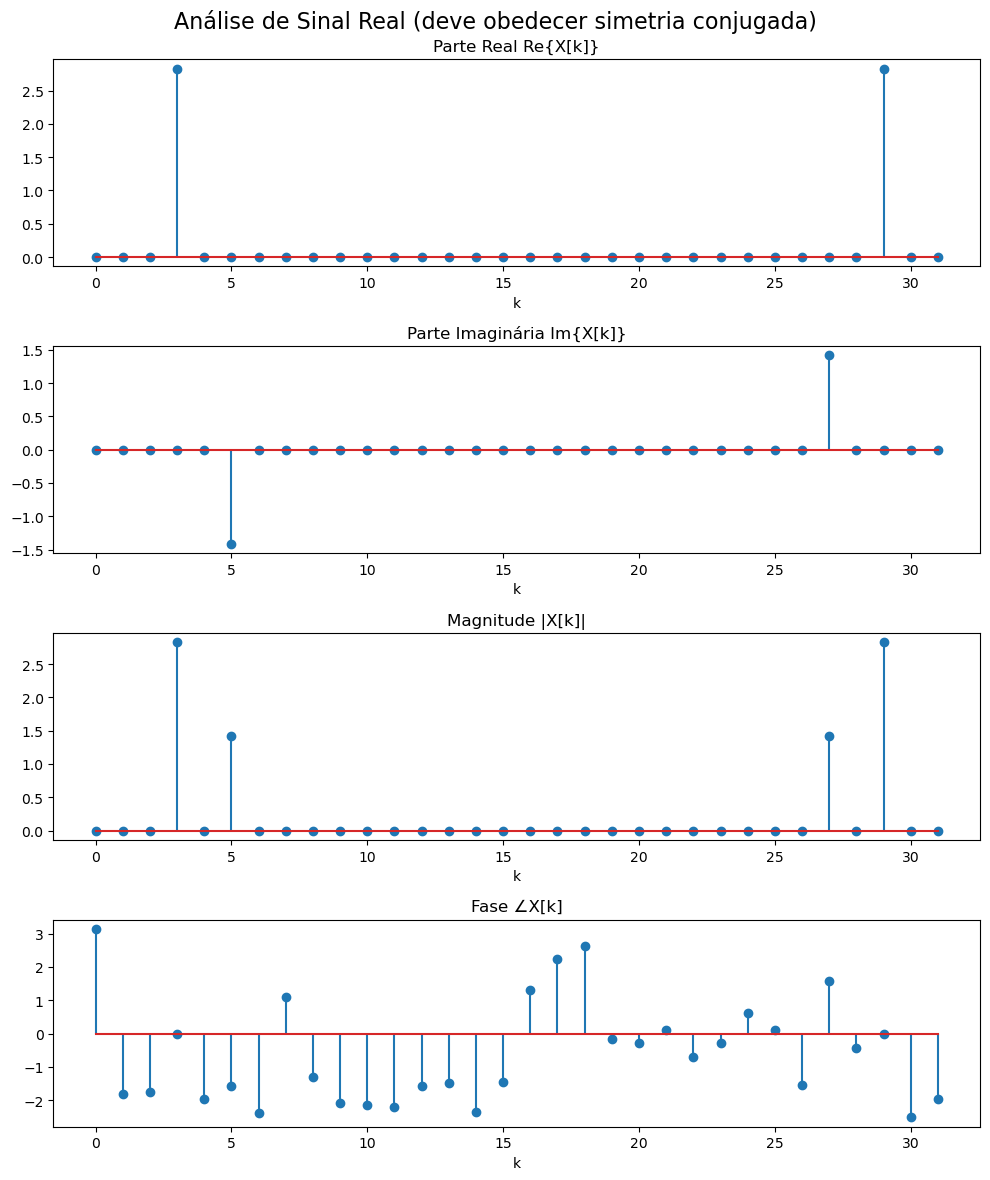

=== Verificação das Simetrias Conjugadas ===
k= 1: Re diff=+9.62e-16,  Im sum=-2.41e-15,  |X| diff=-2.56e-15,  fase sum=+1.09e+00
k= 2: Re diff=+7.73e-15,  Im sum=-2.29e-15,  |X| diff=-8.03e-15,  fase sum=-2.89e-01
k= 3: Re diff=-2.66e-15,  Im sum=+8.00e-15,  |X| diff=-2.66e-15,  fase sum=+2.83e-15
k= 4: Re diff=-6.47e-15,  Im sum=+1.49e-15,  |X| diff=-6.45e-15,  fase sum=+1.48e+00
k= 5: Re diff=+2.83e+00,  Im sum=-1.40e-14,  |X| diff=+6.44e-15,  fase sum=-3.14e+00
k= 6: Re diff=+3.73e-16,  Im sum=-2.26e-15,  |X| diff=-6.99e-16,  fase sum=-4.66e+00
k= 7: Re diff=-4.05e-15,  Im sum=+2.87e-15,  |X| diff=-2.88e-15,  fase sum=+1.95e+00
k= 8: Re diff=-3.33e-15,  Im sum=+1.86e-15,  |X| diff=-2.83e-15,  fase sum=-1.22e+00
k= 9: Re diff=-2.15e-15,  Im sum=-3.14e-16,  |X| diff=+5.59e-16,  fase sum=-1.74e+00
k=10: Re diff=-1.23e-15,  Im sum=-2.08e-15,  |X| diff=-1.16e-15,  fase sum=-4.34e+00
k=11: Re diff=-5.59e-15,  Im sum=-4.71e-16,  |X| diff=-3.22e-15,  fase sum=-2.20e+00
k=12: Re diff=-2.05e

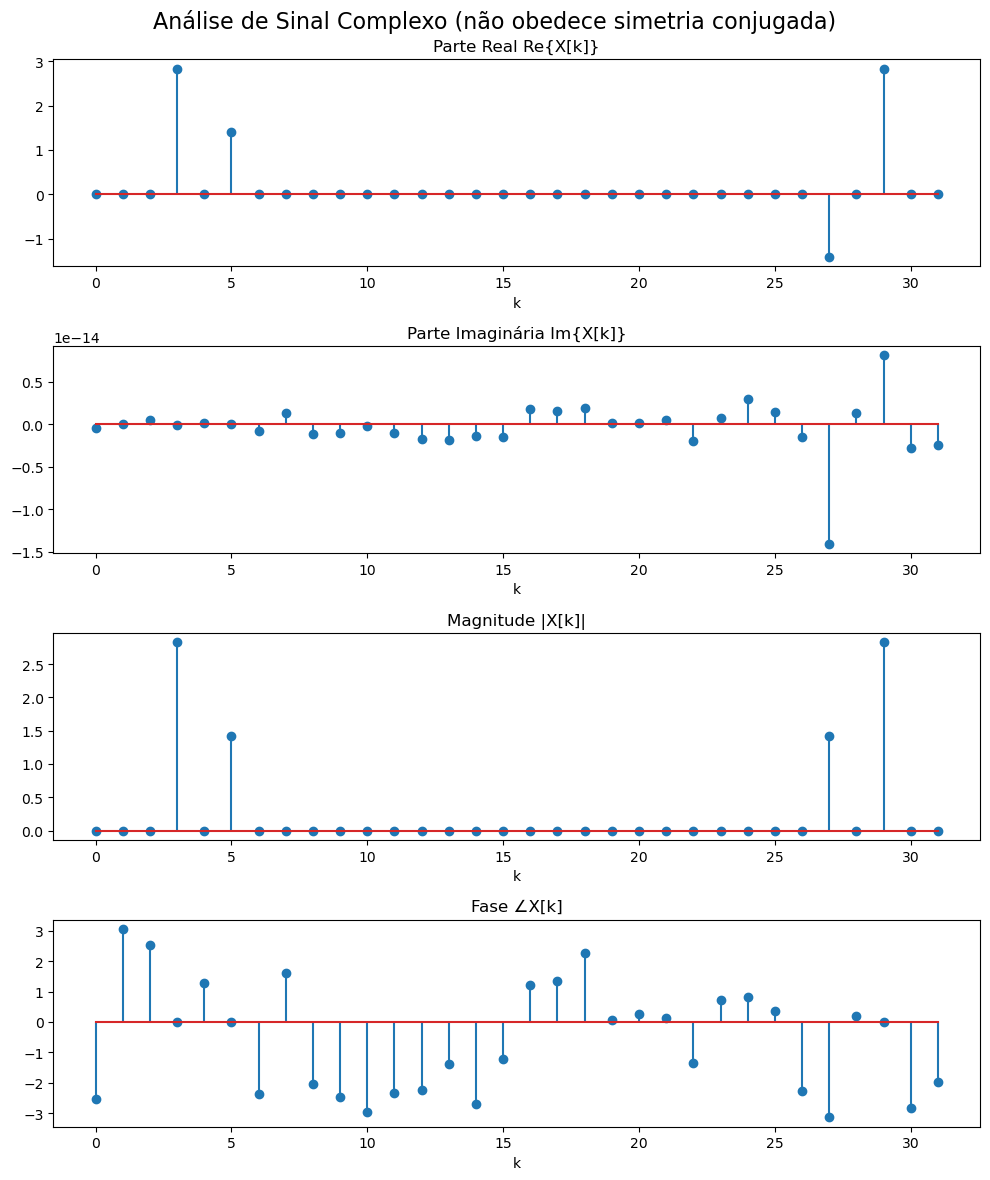

array([-6.28036983e-16-4.21962348e-16j, -5.88784672e-17+4.90653893e-18j,
       -6.67289295e-16+4.61214660e-16j,  2.82842712e+00-1.03037318e-16j,
        5.88784672e-17+1.96261557e-16j,  1.41421356e+00+5.88784672e-17j,
       -8.63550852e-16-8.24298541e-16j, -3.92523115e-17+1.39345706e-15j,
       -5.49532361e-16-1.09906472e-15j, -1.31004590e-15-1.05981241e-15j,
       -8.14485463e-16-1.37383090e-16j, -9.81307787e-16-1.04018625e-15j,
       -1.30513936e-15-1.66822324e-15j,  3.53270803e-16-1.78598017e-15j,
       -3.10093261e-15-1.41308321e-15j,  5.49532361e-16-1.51121399e-15j,
        6.67289295e-16+1.77616709e-15j,  3.53270803e-16+1.62406439e-15j,
       -1.60934477e-15+1.90373711e-15j,  2.00186788e-15+1.57009246e-16j,
        7.45793918e-16+1.86448479e-16j,  4.61214660e-15+5.69158516e-16j,
        4.12149270e-16-1.94298942e-15j,  8.43924697e-16+7.45793918e-16j,
        2.77710104e-15+2.96354952e-15j,  4.01354885e-15+1.47196168e-15j,
       -1.23644781e-15-1.43270937e-15j, -1.41421356

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

def DFT_simetry(x, N, titulo=""):
    # 1. DFT
    X = DFT_func(x, N)

    # 2. Extrair componentes
    k = np.arange(N)
    Re_X = np.real(X)
    Im_X = np.imag(X)
    Mag_X = np.abs(X)
    Fase_X = (np.arctan2(np.imag(X), np.real(X)))


    # 3. Verificação das simetrias
    print("=== Verificação das Simetrias Conjugadas ===")
    for k1 in range(1, N//2):    # exclui k=0 e N/2
        re_diff = Re_X[k1] - Re_X[N-k1]
        im_sum  = Im_X[k1] + Im_X[N-k1]
        mag_diff= Mag_X[k1] - Mag_X[N-k1]
        fase_sum= Fase_X[k1] + Fase_X[N-k1]
        print(f"k={k1:2d}: Re diff={re_diff:+.2e},  "
              f"Im sum={im_sum:+.2e},  "
              f"|X| diff={mag_diff:+.2e},  "
              f"fase sum={fase_sum:+.2e}")

    # Casos especiais
    print("\nCasos especiais:")
    print(f"X[0] = {X[0]}  (DC, deve ser real p/ sinal real)")
    if N % 2 == 0:
        print(f"X[N/2] = X[{N//2}] = {X[N//2]}  (frequência de Nyquist, deve ser real p/ sinal real)")

    # 4. Gráficos
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))
    fig.suptitle(f"Análise de {titulo}", fontsize=16)

    axs[0].stem(k, Re_X)
    axs[0].set_title("Parte Real Re{X[k]}")
    axs[0].set_xlabel("k")

    axs[1].stem(k, Im_X)
    axs[1].set_title("Parte Imaginária Im{X[k]}")
    axs[1].set_xlabel("k")

    axs[2].stem(k, Mag_X)
    axs[2].set_title("Magnitude |X[k]|")
    axs[2].set_xlabel("k")

    axs[3].stem(k, Fase_X)
    axs[3].set_title("Fase ∠X[k]")
    axs[3].set_xlabel("k")

    plt.tight_layout()
    plt.show()

    return X


N = 32
n = np.arange(N)

    # ---------- Sinal real ----------
x_real = np.cos(2*np.pi*3*n/N) + 0.5*np.sin(2*np.pi*5*n/N)

    # ---------- Sinal complexo ----------
x_complex = np.cos(2*np.pi*3*n/N) + 0.5j*np.sin(2*np.pi*5*n/N)

    # ---------- Análises ----------
DFT_simetry(x_real, N, "Sinal Real (deve obedecer simetria conjugada)")
DFT_simetry(x_complex, N, "Sinal Complexo (não obedece simetria conjugada)")


## Transformada Inversa Discreta de Fourier (IDFT)

A **IDFT** permite reconstruir o sinal original $x[n]$ a partir dos coeficientes $X[k]$. Com a normalização unitária, a IDFT é:

$$
\boxed{
x[n] = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} X[k] \, e^{j \frac{2 \pi}{N} k n},
\quad n = 0,1,2,\dots,N-1
}
$$


## Conceito de $W_N$

Definimos a raiz $N$-ésima da unidade (conhecida como "twiddle factor") como:

$$
\boxed{
W_N = e^{-j \frac{2 \pi}{N}}
}
$$

Usando esta notação, as transformadas simétricas se tornam:

A **DFT** pode ser escrita como:
$$
\boxed{
X[k] = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x[n] \, W_N^{kn},
\quad k = 0,1,2,\dots,N-1
}
$$

E a **IDFT** como:
$$
\boxed{
x[n] = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} X[k] \, W_N^{-kn},
\quad n = 0,1,2,\dots,N-1
}
$$

onde:
$$
\boxed{
W_N^{-kn} = e^{j \frac{2 \pi}{N} k n}
}
$$


## Observações importantes

- A propriedade da **linearidade** continua válida. A transformada de uma combinação linear de sinais é a combinação linear de suas transformadas.
- Para sinais **reais**, a parte imaginária do resultado da IDFT deve ser próxima de zero (desconsiderando pequenos erros numéricos de ponto flutuante).
- A complexidade computacional de uma implementação direta permanece $O(N^2)$. Para sinais grandes, algoritmos de **FFT** (Fast Fourier Transform) são recomendados.
- Receber $N$ como parâmetro permite:
  - **Zero-padding** (preenchimento com zeros) quando $N > \text{len}(X[k])$
  - **Truncamento** quando $N < \text{len}(X[k])$

In [12]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def IDFT_func(X_k, N):
    L = len(X_k)  # tamanho do vetor de frequência

    # Inicializa vetor ajustado de tamanho N (com zeros)
    X_adj = np.zeros(N, dtype=X_k.dtype)
    if L < N:
        X_adj[:L] = X_k  # zero padding
    else:
        X_adj = X_k[0:N]  # truncar

    # Inicializa o vetor de saída
    x = np.zeros(N, dtype=np.complex128)

    # Cálculo da IDFT (sinal positivo no expoente)
    for n in prange(N):
        for k in range(N):
            x[n] += X_adj[k] * np.exp((2j * np.pi * k * n) / N)

    return x / np.sqrt(N)  # normalização igual à da DFT




# Convolução Circular via DFT

Em processamento digital de sinais, a **convolução linear** é uma operação fundamental. O **Teorema da Convolução** para a Transformada Discreta de Fourier (DFT) oferece um método alternativo para seu cálculo, transformando a convolução no domínio do tempo em uma simples multiplicação no domínio da frequência.

Contudo, a DFT, por sua natureza, calcula a **convolução circular**. Este documento demonstra a condição e o procedimento necessários para que o resultado da convolução circular seja idêntico ao da convolução linear.

## 1\. Convolução Linear

Considere dois sinais de duração finita:

  - $x[n]$, com comprimento $K$ (não nulo para $n=0, 1, \dots, K-1$)
  - $h[n]$, com comprimento $L$ (não nulo para $n=0, 1, \dots, L-1$)

A convolução linear entre eles, denotada por $y_L[n] = x[n] * h[n]$, é definida pela soma:

$$y_L[n] = \sum_{m=0}^{K-1} x[m] h[n-m]$$

Uma propriedade crucial da convolução linear é que o sinal resultante, $y_L[n]$, terá um comprimento de **$M = K + L - 1$**.

## 2\. O Teorema da Convolução e a Convolução Circular

O Teorema da Convolução para a DFT estabelece que a multiplicação das DFTs de dois sinais corresponde à DFT de sua convolução circular.

$$\text{IDFT}\{ X[k] \cdot H[k] \} = x[n] \circledast h[n]$$

Onde $\circledast$ denota a convolução circular de N-pontos. O problema é que a convolução circular assume que os sinais são periódicos com período $N$. Isso causa um efeito de "wrap-around" (ou rebatimento no tempo), onde o final do sinal resultante "dá a volta" e se soma ao seu início.


## 3. A Condição para Equivalência

Para que o resultado da convolução circular, $y_c[n]$, seja idêntico ao da convolução linear, $y_L[n]$, precisamos evitar completamente o efeito de "wrap-around".

O sinal resultante da convolução linear, $y_L[n]$, tem comprimento $M = K + L - 1$. Portanto, para que a convolução circular de N-pontos possa conter todo o resultado sem rebatimento, o tamanho da DFT deve ser, no mínimo, igual ao comprimento do resultado linear.

Assim, a condição para a equivalência é:

$$N \geq K + L - 1$$

## 4. Procedimento Prático: Convolução Linear com DFT

Para calcular a convolução linear $y_L[n]$ usando a DFT, seguimos os seguintes passos:

1.  **Definir o Comprimento da DFT:** Calcule o comprimento mínimo necessário: $M = K + L - 1$. Escolha um tamanho de DFT $N$ que satisfaça $N \geq M$.

2.  **Preenchimento com Zeros (Zero-Padding):** Crie novos sinais de comprimento $N$, $x_N[n]$ e $h_N[n]$, preenchendo os sinais originais com zeros para evitar o rebatimento.

    - Para $x_N[n]$:
    $$
    x_N[n] = [x[0], x[1], \dots, x[K-1], \underbrace{0, 0, \dots, 0}_{N-K \text{ zeros}}]
    $$

    - Para $h_N[n]$:
    $$
    h_N[n] = [h[0], h[1], \dots, h[L-1], \underbrace{0, 0, \dots, 0}_{N-L \text{ zeros}}]
    $$

3.  **Calcular as DFTs:** Calcule as DFTs de N-pontos dos sinais preenchidos com zeros:
    - $X_N[k] = \text{DFT}\{x_N[n]\}$
    - $H_N[k] = \text{DFT}\{h_N[n]\}$

4.  **Multiplicar no Domínio da Frequência:** Multiplique as duas transformadas ponto a ponto:
    $$
    Y_N[k] = X_N[k] \cdot H_N[k]
    $$

5.  **Calcular a IDFT:** Calcule a Transformada Inversa Discreta de Fourier de N-pontos para obter o resultado no domínio do tempo:
    $$
    y[n] = \text{IDFT}\{Y_N[k]\}
    $$

O sinal resultante $y[n]$ terá comprimento $N$. As primeiras $K+L-1$ amostras de $y[n]$ serão idênticas ao resultado da convolução linear $y_L[n]$. As amostras restantes serão zero.

### Conclusão

Ao aplicar o **zero-padding** de forma a satisfazer a condição $N \geq K+L-1$, garantimos que o rebatimento temporal da convolução circular não ocorra. Dessa forma, podemos usar a multiplicação no domínio da frequência via DFT para calcular com exatidão a convolução linear entre dois sinais.



In [ ]:
#Função de convolução do Capítulo 1

def conv(x, h , mode="full"):


    """
    Realiza a convolução entre dois sinais discretos x e h.
    O parâmetro 'mode' controla o tipo de convolução:
    - 'full': Convolução completa
    - 'valid': Convolução válida
    - 'same': Convolução com o mesmo tamanho do sinal de entrada x
    """


    #definir o tamanho dos sinais e onde havera convolução
    M = len(x)  # Tamanho do sinal x
    N = len(h)  # Tamanho do sinal h
    y= np.zeros(M + N - 1)  # Cria um vetor de zeros para armazenar o resultado da convolução com o tamanho (M + N - 1)

    for n in range(M + N - 1):#Laço para percorrer o tamanho (M + N - 1)
        for k in range(M): #dentro de outro laço para percorrer o tamanho de y(vetor de zeros da saida)
            if 0 <= n - k < N: # condição para verificar se o índice n-k está dentro dos limites do vetor y
                y[n] += x[k] * h[n - k]  # Realiza a convolução
    if mode == "full":  # Se o modo for 'full', retorna a convolução completa
        # A saída terá tamanho M + N - 1, que é o tamanho máximo da convolução
        return y

    elif mode == "same":  # Se o modo for 'same', retorna apenas a parte válida da convolução
        # Retorna a parte central da convolução, que tem o mesmo tamanho que o sinal de entrada x
        # A saida vai ter o mesmo numero de pontos que a entrada x(n)
        
        n_elements_cutted= (len(y) - len(x))  # Calcula o número de elementos a serem cortados
        centralized_idx = n_elements_cutted // 2  # Calcula o índice central para cortar o inicio

        #a divisao inteira // é usada para garantir que o índice seja um número inteiro e caso for impar, o valor central será o mais próximo do meio

        y = y[centralized_idx:centralized_idx + len(x)]  # Corta a convolução para manter o tamanho do sinal de entrada x
        #corta o array [inicio:final+1] para manter o tamanho do sinal de entrada x
        return y
    elif mode == "valid":  # Se o modo for 'valid', retorna apenas a parte válida da convolução
        # Retorna a parte válida da convolução, que é a parte onde ambos os sinais se sobrepõem completamente
        start= N-1
        end= M
        y=y[start:end]  # Corta a convolução para manter apenas a parte válida
        return y
    else :
        raise ValueError("Modo inválido. Use 'full', 'same' ou 'valid'.")  

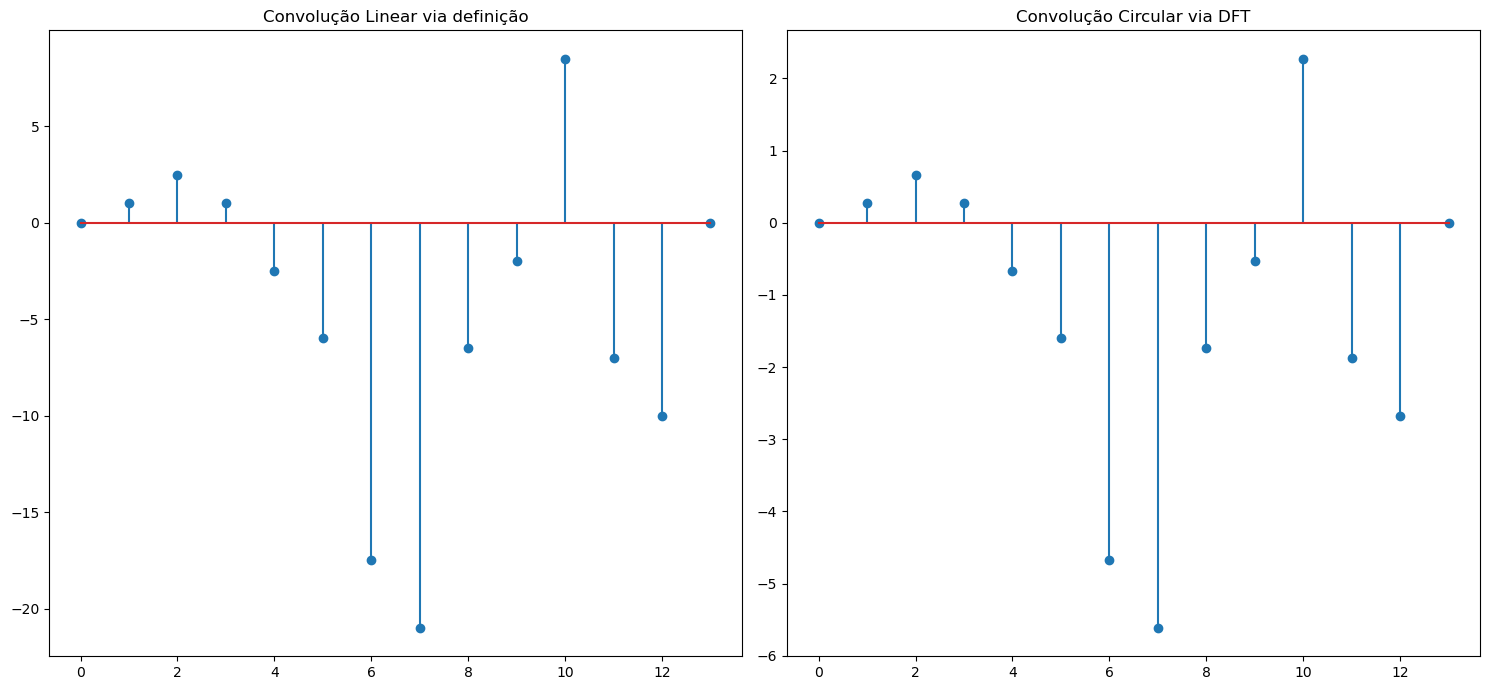

In [18]:
x_1= np.array([1, 2, 3, 4, 5, -2, 3, -4, 5 ])
h_1= np.array([0, 1, 0.5, -3, -2, 0])

Np= len(x_1) + len(h_1) - 1 #número de pontos para evitar o rebatimento temporal

x1_DFT= DFT_func(x_1, N= Np)
h1_DFT= DFT_func(h_1, N= Np)

X1_h1_DFT= x1_DFT * h1_DFT

Conv_circ= IDFT_func(X1_h1_DFT, N=Np)

Conv_lin= conv(x_1,h_1, mode="full")

fig, axs= plt.subplots(1,2, figsize=(15,7))
axs[0].stem(Conv_lin)
axs[0].set_title('Convolução Linear via definição')
axs[1].stem(Conv_circ)
axs[1].set_title('Convolução Circular via DFT')
plt.tight_layout()
plt.show()



# Transformada Rápida de Fourier (FFT)

A **Transformada Discreta de Fourier (DFT)** de um sinal discreto $x[n]$ de comprimento $N$ é definida como:

$$
X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}, \quad k = 0,1,\dots,N-1
$$

onde $X[k]$ representa a amplitude e fase das componentes de frequência do sinal.

---

## Complexidade da DFT

A implementação direta da DFT possui complexidade de:

$$
O(N^2)
$$

para um sinal de $N$ pontos, pois cada saída $X[k]$ requer $N$ multiplicações e somas.

---

## FFT – Transformada Rápida de Fourier

A **FFT (Fast Fourier Transform)** é um algoritmo eficiente para calcular a DFT, explorando a simetria e periodicidade dos coeficientes complexos (conhecidos como *twiddle factors*):

$$
W_N^k = e^{-j \frac{2 \pi k}{N}}
$$

### Algoritmo de Cooley-Tukey (Radix-2)

1.  O sinal $x[n]$ é **reordenado por bit-reversal**.
2.  Aplicam-se etapas de **"butterfly"**, combinando pares de pontos do sinal com os fatores $W_N^k$.
3.  O processo é iterativo (ou recursivo) até que todos os $N$ pontos sejam processados.

A FFT reduz a complexidade da DFT para:

$$
O(N \log_2 N)
$$

---

## Observações

- A FFT mantém as mesmas amplitudes e fases da DFT direta.
- Para sinais reais, apenas $N/2$ componentes positivas são suficientes para análise completa.
- A normalização pode ser feita dividindo por $N$ ou $\sqrt{N}$, dependendo da convenção adotada.

> **Referência:** > DINIZ, Paulo S. R., *Sistemas Digitais e Processamento de Sinais: Fundamentos e Aplicações*. 2ª edição, LTC, 2011.

In [31]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def bits_reverse(N):
    """
    Gera um vetor de índices de 0 a N-1 com a ordem invertida em bits.
    Usado na reorganização do vetor de entrada da FFT radix-2.
    
    Parâmetro:
        N : int
            Tamanho do vetor (deve ser potência de 2)
    
    Retorno:
        indices_reversos : ndarray de int
            Vetor de índices com bits invertidos
    """
    bits = int(np.log2(N))
    indices_reversos = np.zeros(N, dtype=np.int32)

    for i in prange(N):
        rev = 0
        temp = i
        for b in range(bits):
            rev = (rev << 1) | (temp & 1)
            temp >>= 1
        indices_reversos[i] = rev

    return indices_reversos

In [49]:
def FFT_func(x, N):
    """
    FFT radix-2 iterativa (Cooley-Tukey) com Numba e normalização 1/sqrt(N).
    
    A função automaticamente aplica zero-padding para que o tamanho final (N_fft)
    seja a próxima potência de 2 maior ou igual a N.
    
    Entradas:
        x : vetor real ou complexo de entrada.
        N : número mínimo de pontos desejado para a FFT.
    
    Saída:
        X : vetor da FFT.
        N_fft: o tamanho real (potência de 2) usado na FFT.
    """
    L = len(x)
    
    # 1. Calcula o tamanho real da FFT (próxima potência de 2)
    #    (Ex: se N_desejado=7200, N_fft será 8192)
    if N <= 1:
        N_fft = 1
    else:
        N_fft = 1 << (N - 1).bit_length()

    # 2. Inicializa vetor complexo X com tamanho N_fft e aplica zero-padding
    X = np.zeros(N_fft, dtype=np.complex128)
    # Copia os dados de x para X. Se L > N_fft, trunca. Se L < N_fft, preenche com zeros.
    for i in range(min(L, N_fft)):
        X[i] = complex(x[i])
    
    # 3. Reordenação bit-reversal
    indices = bits_reverse(N_fft)
    X = X[indices]
    
    # 4. Estágios da FFT
    stages = int(np.log2(N_fft))
    for s in range(1, stages + 1):
        m = 2 ** s
        wm = np.exp(-2j * np.pi / m)
        for k in range(0, N_fft, m):
            w = 1.0 + 0j
            for j in range(m // 2):
                u = X[k + j]
                t = w * X[k + j + m // 2]
                X[k + j] = u + t
                X[k + j + m // 2] = u - t
                w *= wm
    
    # 5. Normalização
    norm = 1 / np.sqrt(N_fft)
    for i in range(N_fft):
        X[i] *= norm
    
    return X, N_fft # Retorna o resultado e o N efetivamente usado


In [35]:
def fft_freq(N, Ts):
    
    freqs = np.zeros(N)
    
    for k in range(N):
        
        if k < N//2: # Positive frequencies
            freqs[k] = k / (N * Ts)
            
        else: # Negative frequencies
            freqs[k] = (k - N) / (N * Ts)
            
    return freqs


Tamanho original do sinal: 70
Tamanho da FFT após padding (potência de 2): 128


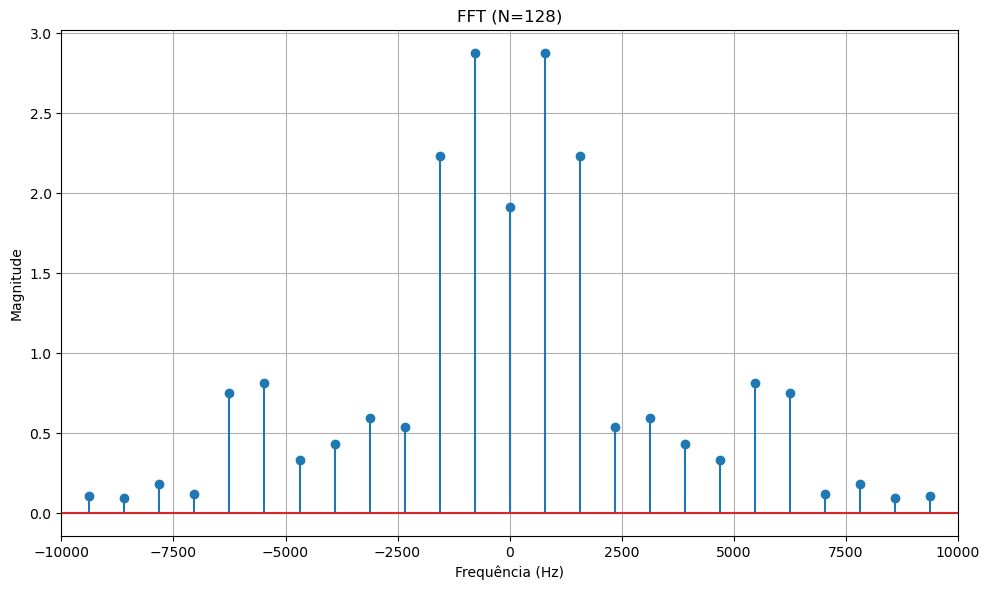

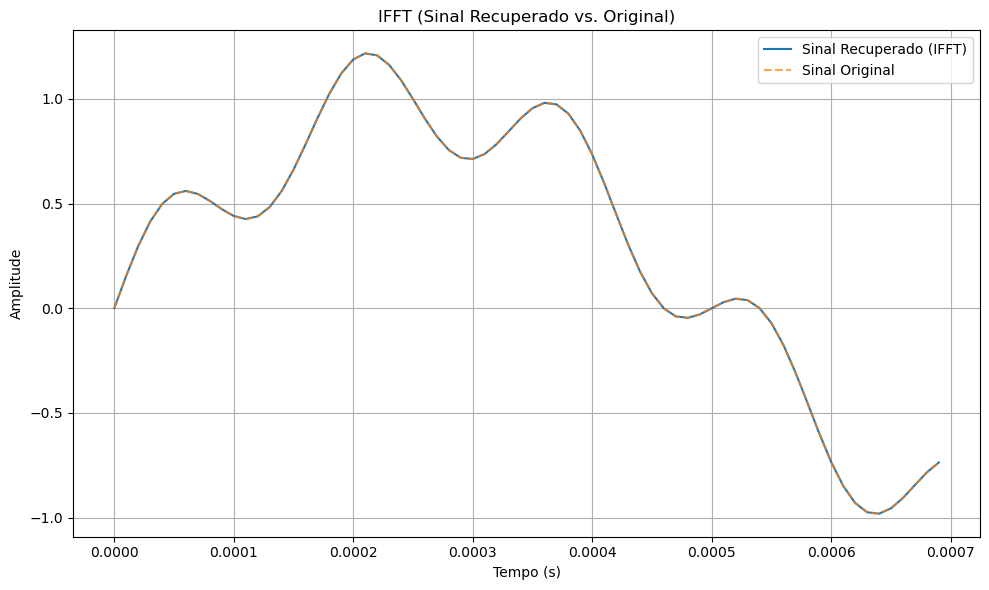

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange


def ifft_iterative(x):
    """
    Implementação da IFFT (radix-2) iterativa com Numba.
    Normalização simétrica: 1/sqrt(N)
    """
    N = len(x)
    X = np.empty_like(x) # Cria uma cópia para não modificar o original
    for i in range(N):
        X[i] = x[i]

    # Reordenação bit-reversal
    indices = bits_reverse(N)
    X = X[indices]

    # Estágios (sinal invertido nos expoentes)
    stages = int(np.log2(N))
    for s in range(1, stages + 1):
        m = 2 ** s
        wm = np.exp(+2j * np.pi / m)
        for k in range(0, N, m):
            w = 1.0 + 0j
            for j in range(m // 2):
                u = X[k + j]
                t = w * X[k + j + m // 2]
                X[k + j] = u + t
                X[k + j + m // 2] = u - t
                w *= wm

    # Normalização simétrica
    return X / np.sqrt(N)



def fft_freq(N, Ts):
    
    freqs = np.zeros(N)
    
    for k in range(N):
        
        if k < N//2: # Positive frequencies
            freqs[k] = k / (N * Ts)
            
        else: # Negative frequencies
            freqs[k] = (k - N) / (N * Ts)
            
    return freqs



N = 70  # Tamanho original do sinal
Fs = 100e3
Ts = 1 / Fs
f1 = 1e3
f2 = 6e3

# Gera o sinal com N pontos
x_time = np.linspace(0.0, N * Ts, N, endpoint=False)
y_signal = np.sin(f1 * 2.0 * np.pi * x_time) + 0.25 * np.sin(f2 * 2.0 * np.pi * x_time)


# A função agora retorna yf (resultado) e N_fft (o N real usado)
yf, N_fft = FFT_func(y_signal, N)

# Usa N_fft para gerar o eixo de frequência corretamente
freq = fft_freq(N_fft, Ts)

print(f"Tamanho original do sinal: {N}")
print(f"Tamanho da FFT após padding (potência de 2): {N_fft}")


plt.figure(figsize=(10, 6))
# Usamos fftshift para centralizar o espectro em 0 Hz, o que é comum em gráficos
plt.stem(np.fft.fftshift(freq), np.fft.fftshift(np.abs(yf)))
plt.grid(True)
plt.xlim(-10000, 10000)
plt.title(f"FFT (N={N_fft})")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()

# Recupera o sinal original via IFFT
y_recovered = ifft_iterative(yf)

plt.figure(figsize=(10, 6))
# Plota apenas os primeiros N pontos do sinal recuperado contra o tempo original
plt.plot(x_time, y_recovered[:N].real, label="Sinal Recuperado (IFFT)")
plt.plot(x_time, y_signal, linestyle='--', label="Sinal Original", alpha=0.7)
plt.grid(True)
plt.title("IFFT (Sinal Recuperado vs. Original)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

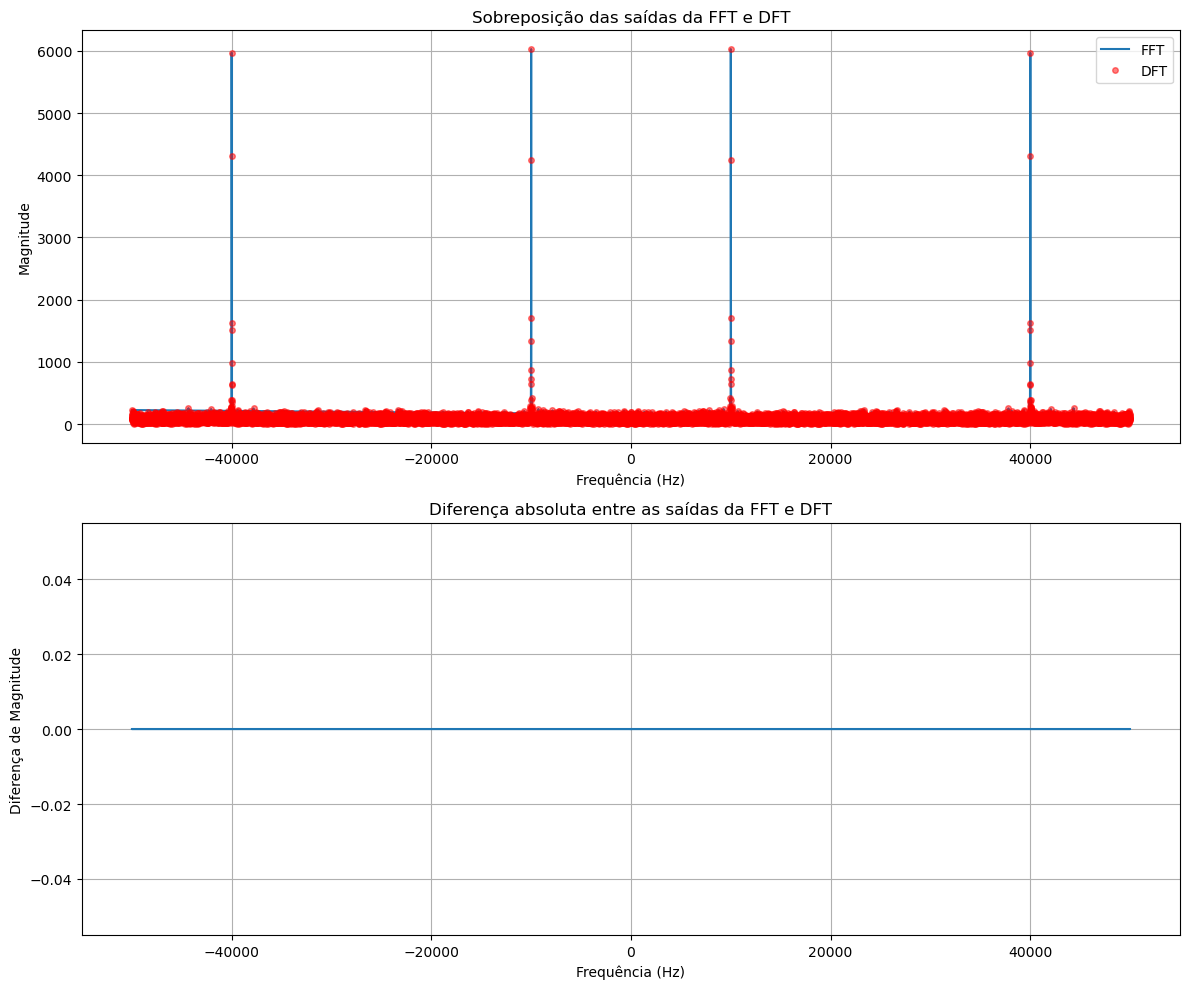

In [ ]:
N = 15000 # Tamanho do sinal
Fs = 100e3 # 100 kHz
Ts = 1 / Fs
f1 = 10e3 # 10 kHz
f2 = 60e3 # 60 kHz

t = np.arange(N) * Ts

x1 = np.sin(2 * np.pi * f1 * t) + 0.5 * np.random.randn(len(t))
x2 = np.sin(2 * np.pi * f2 * t) + 0.5 * np.random.randn(len(t))

xi = x1 + x2

# Cálculos da FFT e DFT
fft1, N_fft = FFT_func(xi, N)
dft1 = DFT_func(xi, N_fft)
freq = fft_freq(N_fft, Ts)

# Gráficos para Comparação Direta 
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# GRÁFICO 1: Sobreposição dos resultados
axs[0].plot(freq, np.abs(fft1), label='FFT')
axs[0].plot(freq, np.abs(dft1), 'ro', label='DFT', markersize=4, alpha=0.5)
axs[0].set_title('Sobreposição das saídas da FFT e DFT')
axs[0].set_xlabel('Frequência (Hz)')
axs[0].set_ylabel('Magnitude')
axs[0].legend()
axs[0].grid(True)

# GRÁFICO 2: Prova matemática da igualdade
diferenca = np.abs(fft1) - np.abs(dft1)
axs[1].plot(freq, diferenca)
axs[1].set_title('Diferença absoluta entre as saídas da FFT e DFT')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Diferença de Magnitude')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Iniciando a comparação de tempo... 
Testando para N = 64...
Testando para N = 128...
Testando para N = 256...
Testando para N = 512...
Testando para N = 1024...
Testando para N = 2048...
Testando para N = 4096...
Testando para N = 8192...
Testando para N = 16384...
Teste finalizado.


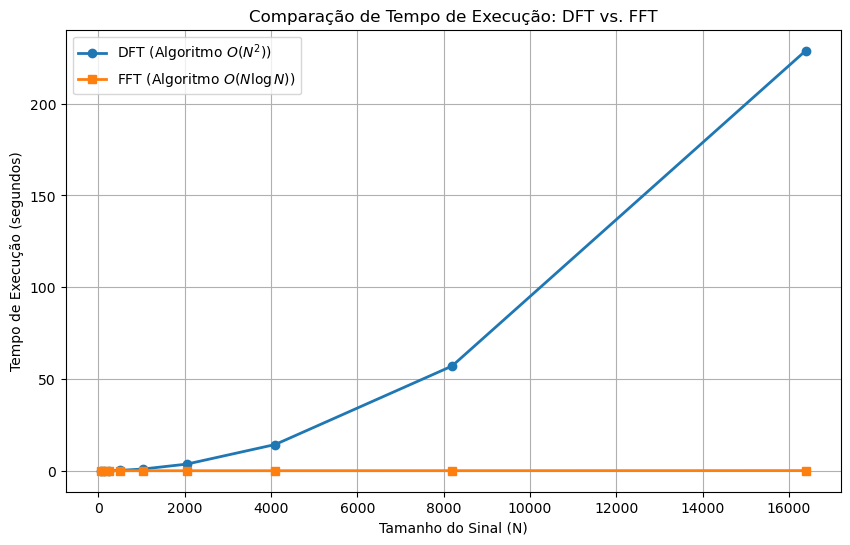

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Implementação Pura da DFT (lenta, para comparação) ---
# Esta função implementa a fórmula matemática da DFT para mostrar
# a diferença de performance.
def DFT_func_puro(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT

def FFT_func_puro(x, N):
    """
    FFT radix-2 iterativa (Cooley-Tukey) com Numba e normalização 1/sqrt(N).
    
    A função automaticamente aplica zero-padding para que o tamanho final (N_fft)
    seja a próxima potência de 2 maior ou igual a N.
    
    Entradas:
        x : vetor real ou complexo de entrada.
        N : número mínimo de pontos desejado para a FFT.
    
    Saída:
        X : vetor da FFT.
        N_fft: o tamanho real (potência de 2) usado na FFT.
    """
    L = len(x)
    
    # 1. Calcula o tamanho real da FFT (próxima potência de 2)
    #    (Ex: se N_desejado=7200, N_fft será 8192)
    if N <= 1:
        N_fft = 1
    else:
        N_fft = 1 << (N - 1).bit_length()

    # 2. Inicializa vetor complexo X com tamanho N_fft e aplica zero-padding
    X = np.zeros(N_fft, dtype=np.complex128)
    # Copia os dados de x para X. Se L > N_fft, trunca. Se L < N_fft, preenche com zeros.
    for i in range(min(L, N_fft)):
        X[i] = complex(x[i])
    
    # 3. Reordenação bit-reversal
    indices = bits_reverse(N_fft)
    X = X[indices]
    
    # 4. Estágios da FFT
    stages = int(np.log2(N_fft))
    for s in range(1, stages + 1):
        m = 2 ** s
        wm = np.exp(-2j * np.pi / m)
        for k in range(0, N_fft, m):
            w = 1.0 + 0j
            for j in range(m // 2):
                u = X[k + j]
                t = w * X[k + j + m // 2]
                X[k + j] = u + t
                X[k + j + m // 2] = u - t
                w *= wm
    
    # 5. Normalização
    norm = 1 / np.sqrt(N_fft)
    for i in range(N_fft):
        X[i] *= norm
    
    return X, N_fft # Retorna o resultado e o N efetivamente usado
# --- Configuração do Teste ---
# Vamos testar para diferentes tamanhos de N.
# Começamos com valores pequenos, pois a DFT pura é muito lenta para N grande.
tamanhos_N = [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
tempos_dft = []
tempos_fft = []

print("Iniciando a comparação de tempo... ")

# --- Loop de Medição ---
for N in tamanhos_N:
    print(f"Testando para N = {N}...")
    # Cria um sinal de teste aleatório
    sinal_teste = np.random.randn(N)

    # Mede o tempo da DFT
    inicio_dft = time.time()
    DFT_func_puro(signal=sinal_teste, N=N)
    fim_dft = time.time()
    tempos_dft.append(fim_dft - inicio_dft)

    # Mede o tempo da FFT
    inicio_fft = time.time()
    FFT_func_puro(sinal_teste, N=N)
    fim_fft = time.time()
    tempos_fft.append(fim_fft - inicio_fft)

print("Teste finalizado.")

# --- Plotando o Gráfico de Comparação ---
plt.figure(figsize=(10, 6))
plt.plot(tamanhos_N, tempos_dft, 'o-', label='DFT (Algoritmo $O(N^2)$)', linewidth=2)
plt.plot(tamanhos_N, tempos_fft, 's-', label='FFT (Algoritmo $O(N \log N)$)', linewidth=2)

plt.title('Comparação de Tempo de Execução: DFT vs. FFT')
plt.xlabel('Tamanho do Sinal (N)')
plt.ylabel('Tempo de Execução (segundos)')
plt.legend()
plt.grid(True)
# Usar escala logarítmica no eixo Y ajuda a visualizar a enorme diferença
#plt.yscale('log')
plt.show()

Iniciando a comparação de tempo... (Isso pode levar alguns segundos)
Compilando a função Numba (primeira chamada)...
Compilação concluída.
Testando para N = 64...
Testando para N = 128...
Testando para N = 256...
Testando para N = 512...
Testando para N = 1024...
Testando para N = 2048...
Testando para N = 4096...
Testando para N = 8192...
Teste finalizado.


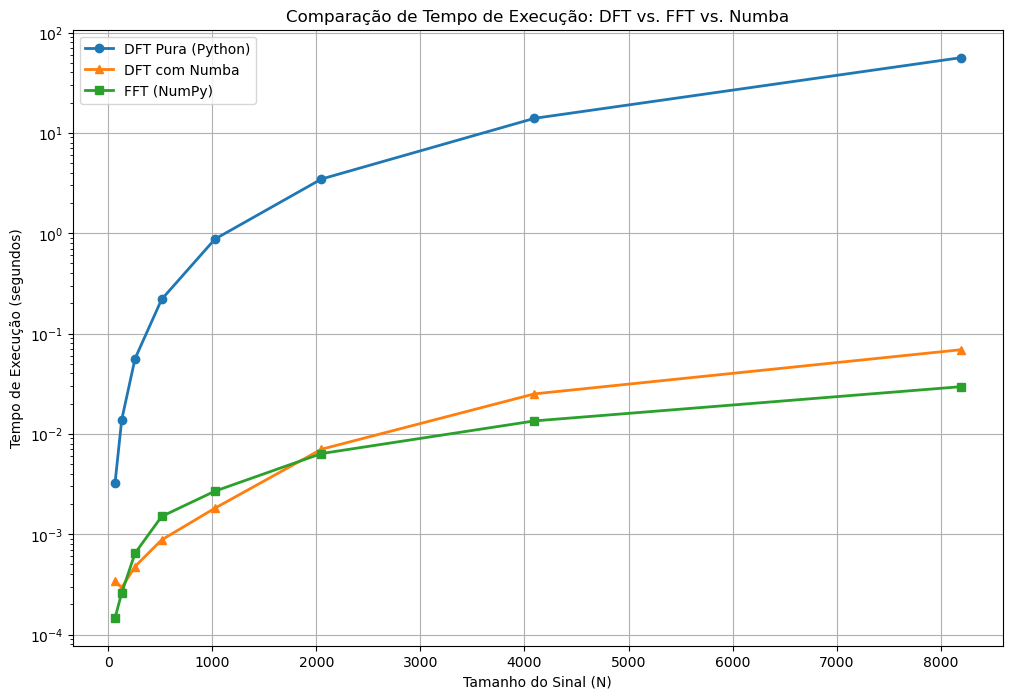

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit

@njit(parallel=True)
def DFT_func_Numba(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT

tamanhos_N = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
tempos_dft = []
tempos_fft = []
tempos_dft_numba = [] # Nova lista para os tempos do Numba

print("Iniciando a comparação de tempo... (Isso pode levar alguns segundos)")

# "Aquecimento" da função Numba: a primeira chamada tem um custo de compilação.
# Fazemos uma chamada inicial para que as medições seguintes sejam justas.
print("Compilando a função Numba (primeira chamada)...")
_ = DFT_func_Numba(np.random.randn(10), 10)
print("Compilação concluída.")


# Loop de Medição 
for N in tamanhos_N:
    print(f"Testando para N = {N}...")
    sinal_teste = np.random.randn(N)

    # Mede o tempo da DFT Pura
    inicio = time.time()
    DFT_func_puro(sinal_teste, N)
    tempos_dft.append(time.time() - inicio)

    # Mede o tempo da FFT
    inicio = time.time()
    FFT_func_puro(sinal_teste, N)
    tempos_fft.append(time.time() - inicio)
    
    # Mede o tempo da DFT com Numba
    inicio = time.time()
    DFT_func_Numba(sinal_teste, N)
    tempos_dft_numba.append(time.time() - inicio)

print("Teste finalizado.")

# Plotando o Gráfico de Comparação 
plt.figure(figsize=(12, 8))
plt.plot(tamanhos_N, tempos_dft, 'o-', label='DFT Pura (Python)', linewidth=2)
plt.plot(tamanhos_N, tempos_dft_numba, '^-', label='DFT com Numba', linewidth=2)
plt.plot(tamanhos_N, tempos_fft, 's-', label='FFT (NumPy)', linewidth=2)

plt.title('Comparação de Tempo de Execução: DFT vs. FFT vs. Numba')
plt.xlabel('Tamanho do Sinal (N)')
plt.ylabel('Tempo de Execução (segundos)')
plt.legend()
plt.grid(True)

plt.yscale('log')

plt.show()